In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

**PART I: Customer Churn**

I. Dataset Familiarization & Preparation

A. Dataset Inspection

In [9]:
# Load the datasets (Update the path if needed)
train_data = pd.read_csv("/kaggle/input/datasets/pywen1004/sa2churn/churn-bigml-80.csv")
test_data = pd.read_csv("/kaggle/input/datasets/pywen1004/sa2churn/churn-bigml-20.csv")

print("Training Data Dimensions:", train_data.shape)
print("Testing Data Dimensions:", test_data.shape)

print("\nData Types:")
print(train_data.info())

print("\nSummary Statistics:")
display(train_data.describe())

Training Data Dimensions: (2666, 20)
Testing Data Dimensions: (667, 20)

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total ni

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


B. Data Cleaning and Preparation

In [10]:
def prepare_churn_data(df):
    df_clean = df.copy()
    
    # Drop State and Area code
    df_clean = df_clean.drop(columns=['State', 'Area code'], errors='ignore')
    
    # Convert Churn to binary (1/0)
    df_clean['Churn'] = df_clean['Churn'].astype(int)
    
    # Convert Yes/No columns to 1/0
    if 'International plan' in df_clean.columns:
        df_clean['International plan'] = df_clean['International plan'].map({'Yes': 1, 'No': 0})
    if 'Voice mail plan' in df_clean.columns:
        df_clean['Voice mail plan'] = df_clean['Voice mail plan'].map({'Yes': 1, 'No': 0})
        
    return df_clean

train_clean = prepare_churn_data(train_data)
test_clean = prepare_churn_data(test_data)

display(train_clean.head())

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


II. Exploratory Data Analysis
1. Churn Rate & Class Imbalance Analysis

Churn Counts:
 Churn
0    2278
1     388
Name: count, dtype: int64

Churn Percentages:
 Churn
0    85.446362
1    14.553638
Name: proportion, dtype: float64


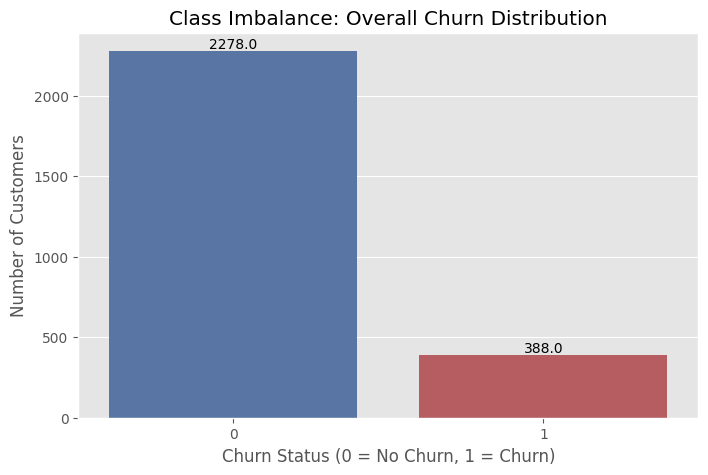

In [11]:
churn_counts = train_clean['Churn'].value_counts()
churn_rate = train_clean['Churn'].value_counts(normalize=True) * 100

print("Churn Counts:\n", churn_counts)
print("\nChurn Percentages:\n", churn_rate)

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Churn', data=train_clean, palette=['#4C72B0', '#C44E52'])
plt.title('Class Imbalance: Overall Churn Distribution')
plt.xlabel('Churn Status (0 = No Churn, 1 = Churn)')
plt.ylabel('Number of Customers')

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

2. Distribution of Important Variables

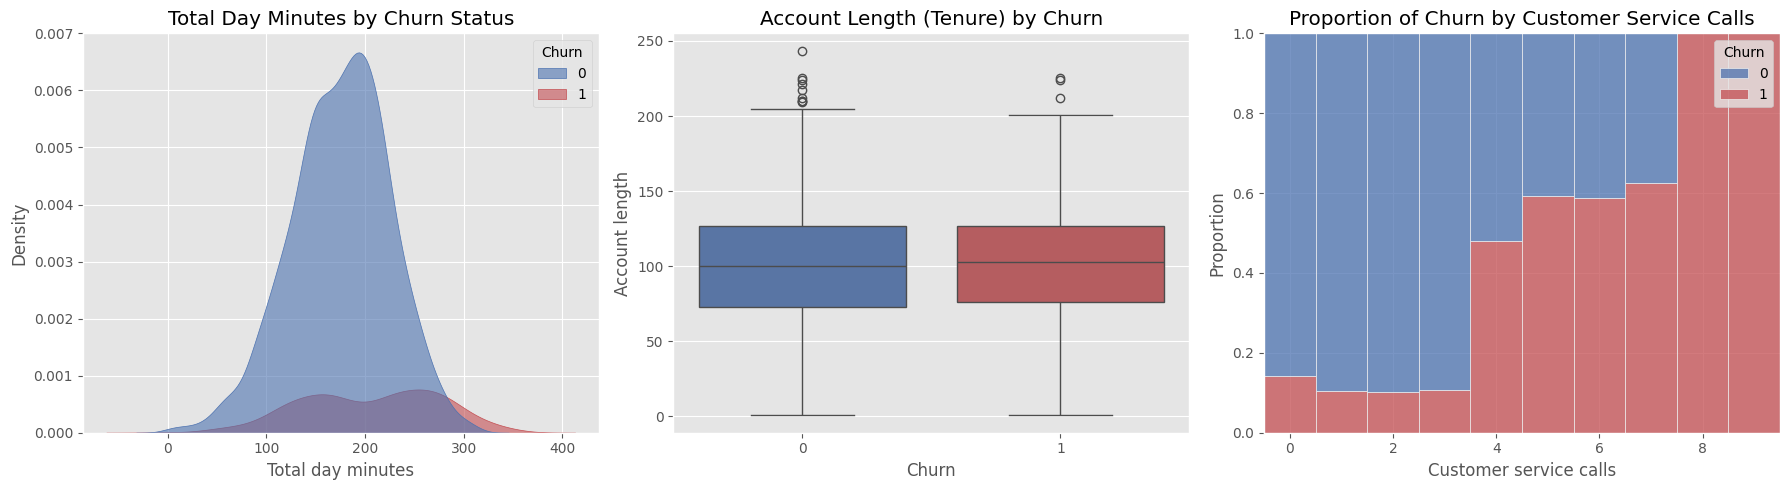

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Total day minutes by Churn
sns.kdeplot(data=train_clean, x='Total day minutes', hue='Churn', fill=True, palette=['#4C72B0', '#C44E52'], ax=axes[0], alpha=0.6)
axes[0].set_title('Total Day Minutes by Churn Status')

# Plot 2: Account Length by Churn
sns.boxplot(data=train_clean, x='Churn', y='Account length', palette=['#4C72B0', '#C44E52'], ax=axes[1])
axes[1].set_title('Account Length (Tenure) by Churn')

# Plot 3: Proportion of Churn by Customer Service Calls
sns.histplot(data=train_clean, x='Customer service calls', hue='Churn', multiple='fill', discrete=True, palette=['#4C72B0', '#C44E52'], ax=axes[2])
axes[2].set_title('Proportion of Churn by Customer Service Calls')
axes[2].set_ylabel('Proportion')

plt.tight_layout()
plt.show()

3. Correlation Analysis among Numerical Variables

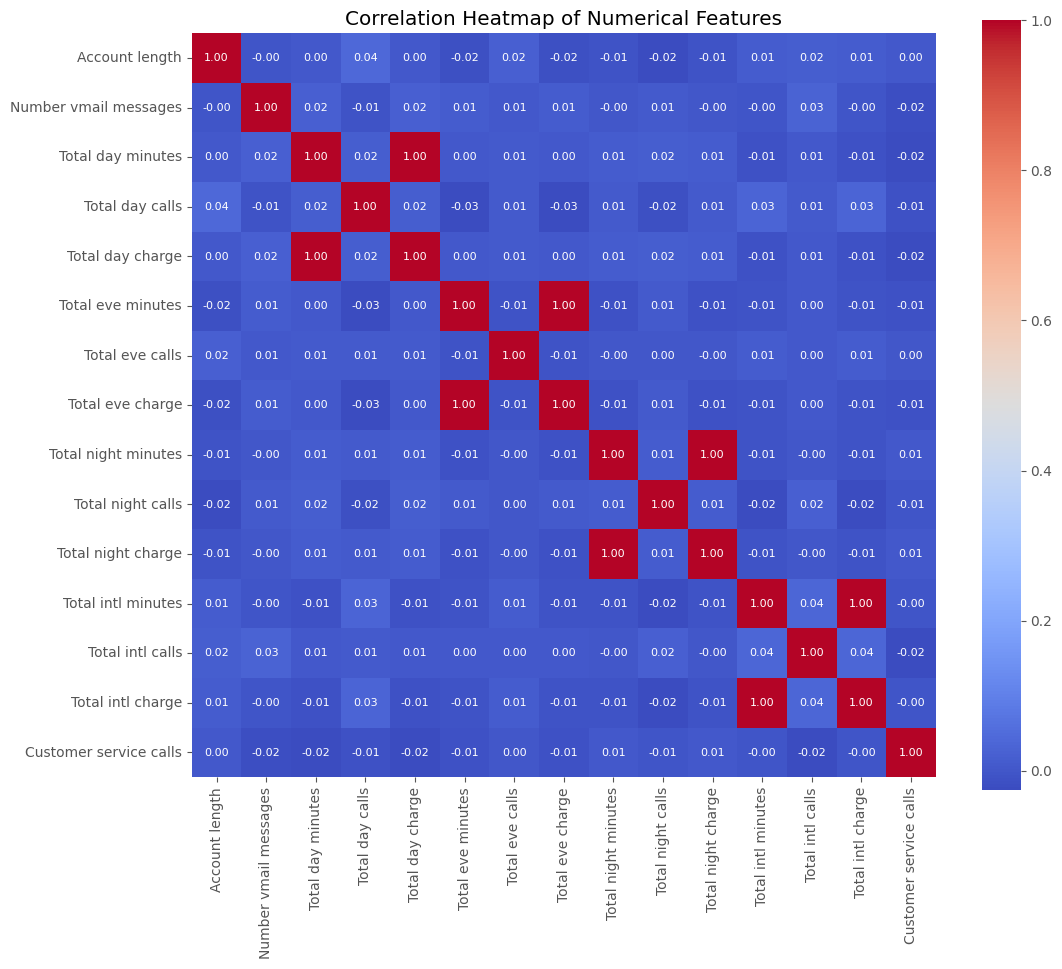

In [13]:
# Drop categorical/target columns for correlation
numeric_vars = train_clean.drop(columns=['Churn', 'International plan', 'Voice mail plan'])

plt.figure(figsize=(12, 10))
cor_matrix = numeric_vars.corr()

# Plot heatmap
sns.heatmap(cor_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, annot_kws={"size": 8})
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

III. Modeling and Comparison

In [14]:
# Define evaluation function
def evaluate_model(predictions, true_labels, prob_predictions):
    cm = confusion_matrix(true_labels, predictions)
    return {
        "Accuracy": accuracy_score(true_labels, predictions),
        "Precision": precision_score(true_labels, predictions, zero_division=0),
        "Recall": recall_score(true_labels, predictions),
        "F1": f1_score(true_labels, predictions),
        "AUC": roc_auc_score(true_labels, prob_predictions)
    }

# Prepare X and y
X_train = train_clean.drop('Churn', axis=1)
y_train = train_clean['Churn']
X_test = test_clean.drop('Churn', axis=1)
y_test = test_clean['Churn']

# Scale the data for Regression models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Regression-Based Models
1. Logistic Regression

In [15]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

log_prob = log_model.predict_proba(X_test_scaled)[:, 1]
log_pred = log_model.predict(X_test_scaled)

log_eval = evaluate_model(log_pred, y_test, log_prob)
print("Logistic Regression Results:", log_eval)

# Display Coefficients
log_coefs = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': log_model.coef_[0]})
display(log_coefs.sort_values(by='Coefficient', ascending=False))

Logistic Regression Results: {'Accuracy': 0.8545727136431784, 'Precision': 0.47368421052631576, 'Recall': 0.18947368421052632, 'F1': 0.2706766917293233, 'AUC': np.float64(0.8260765550239234)}


,Feature,Coefficient
16,Customer service calls,0.661904
1,International plan,0.629652
3,Number vmail messages,0.413974
6,Total day charge,0.340642
4,Total day minutes,0.340551
7,Total eve minutes,0.144036
9,Total eve charge,0.142649
15,Total intl charge,0.142475
13,Total intl minutes,0.136235
12,Total night charge,0.071434


2. Lasso Regression

In [16]:
# Using Logistic Regression with L1 penalty to simulate Lasso for classification (like glmnet with alpha=1)
lasso_model = LogisticRegressionCV(Cs=10, penalty='l1', solver='liblinear', cv=5, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

lasso_prob = lasso_model.predict_proba(X_test_scaled)[:, 1]
lasso_pred = lasso_model.predict(X_test_scaled)

lasso_eval = evaluate_model(lasso_pred, y_test, lasso_prob)
print("Lasso Regression Results:", lasso_eval)

# Display Non-Zero Coefficients
lasso_coefs = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lasso_model.coef_[0]})
display(lasso_coefs[lasso_coefs['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False))

Lasso Regression Results: {'Accuracy': 0.8545727136431784, 'Precision': 0.47368421052631576, 'Recall': 0.18947368421052632, 'F1': 0.2706766917293233, 'AUC': np.float64(0.8261685682738314)}


,Feature,Coefficient
16,Customer service calls,0.644282
1,International plan,0.618113
4,Total day minutes,0.405553
15,Total intl charge,0.264216
6,Total day charge,0.255715
9,Total eve charge,0.151722
7,Total eve minutes,0.116696
3,Number vmail messages,0.081746
12,Total night charge,0.065358
10,Total night minutes,0.060414


Tree-Based Models
3. Decision Tree

Decision Tree Results: {'Accuracy': 0.952023988005997, 'Precision': 0.8539325842696629, 'Recall': 0.8, 'F1': 0.8260869565217391, 'AUC': np.float64(0.9077383143172616)}


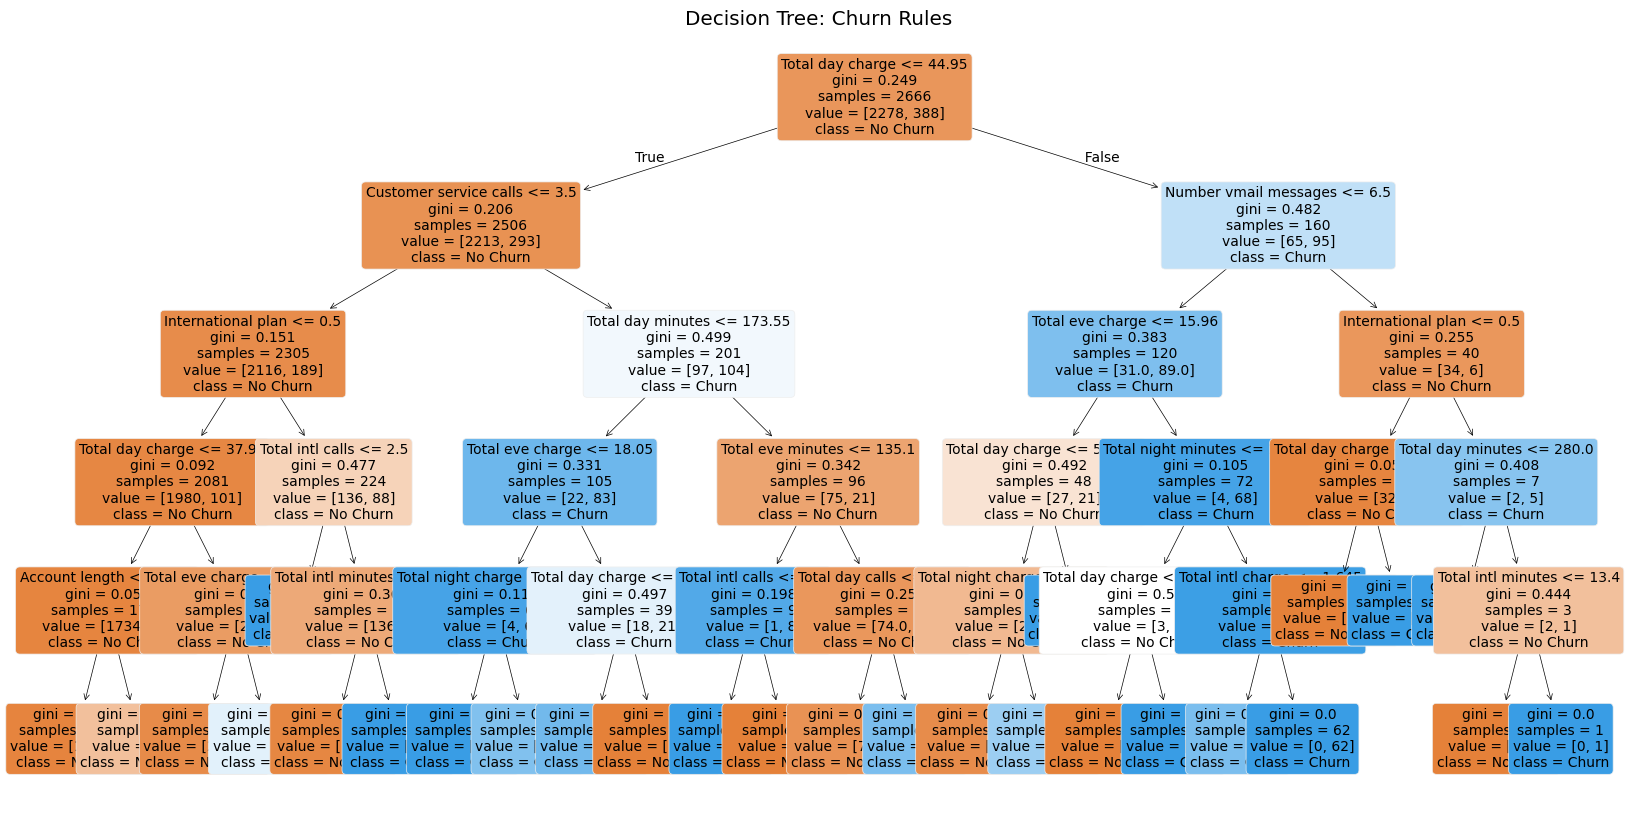

In [23]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_prob = dt_model.predict_proba(X_test)[:, 1]
dt_pred = dt_model.predict(X_test)

dt_eval = evaluate_model(dt_pred, y_test, dt_prob)
print("Decision Tree Results:", dt_eval)

# Plot Decision Tree
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X_train.columns, class_names=['No Churn', 'Churn'], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree: Churn Rules")
plt.show()

4. Random Forest

Random Forest Results: {'Accuracy': 0.9565217391304348, 'Precision': 0.9714285714285714, 'Recall': 0.7157894736842105, 'F1': 0.8242424242424242, 'AUC': np.float64(0.9172616856827382)}


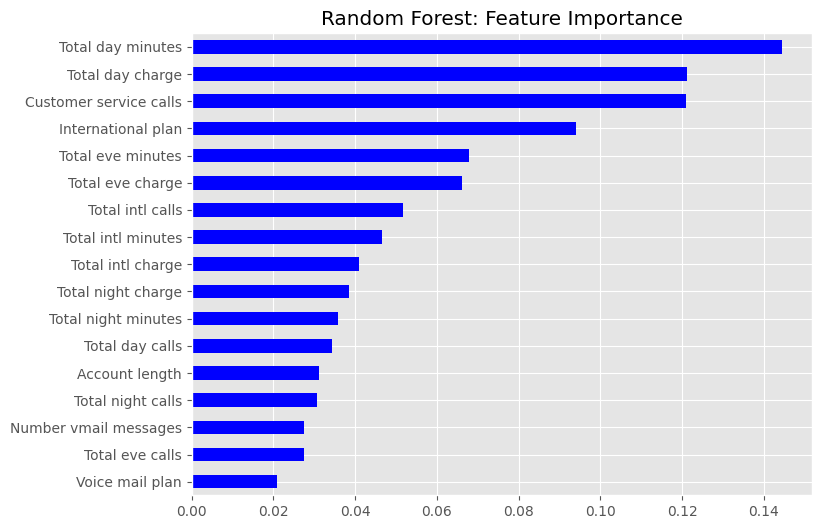

In [18]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=123)
rf_model.fit(X_train, y_train)

rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_pred = rf_model.predict(X_test)

rf_eval = evaluate_model(rf_pred, y_test, rf_prob)
print("Random Forest Results:", rf_eval)

# Feature Importance Plot
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 6))
rf_importances.plot(kind='barh', color='blue')
plt.title("Random Forest: Feature Importance")
plt.show()

5. Gradient Boosting Classifier

Gradient Boosting Results: {'Accuracy': 0.9505247376311844, 'Precision': 0.9305555555555556, 'Recall': 0.7052631578947368, 'F1': 0.8023952095808383, 'AUC': np.float64(0.9266102318733898)}


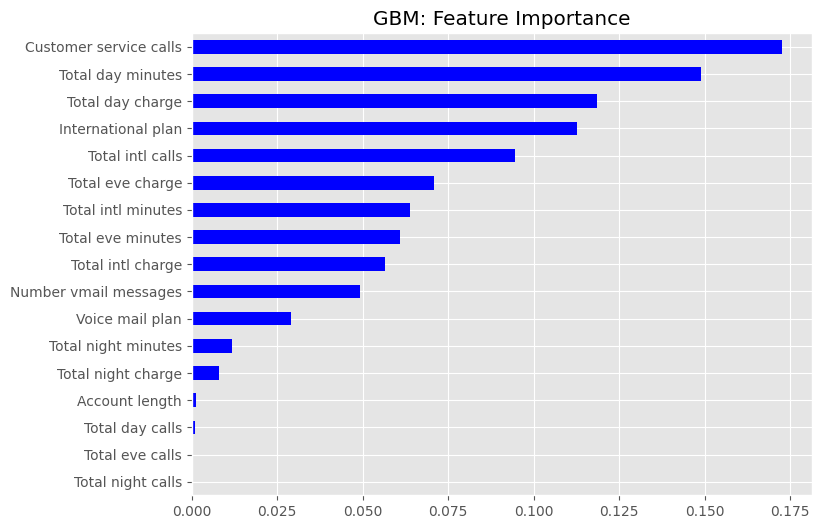

In [19]:
gbm_model = GradientBoostingClassifier(n_estimators=500, max_depth=3, learning_rate=0.01, random_state=123)
gbm_model.fit(X_train, y_train)

gbm_prob = gbm_model.predict_proba(X_test)[:, 1]
gbm_pred = gbm_model.predict(X_test)

gbm_eval = evaluate_model(gbm_pred, y_test, gbm_prob)
print("Gradient Boosting Results:", gbm_eval)

# Feature Importance Plot
gbm_importances = pd.Series(gbm_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 6))
gbm_importances.plot(kind='barh', color='blue')
plt.title("GBM: Feature Importance")
plt.show()

IV. Conclusion and Model Comparison

In [24]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Lasso Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [log_eval['Accuracy'], lasso_eval['Accuracy'], dt_eval['Accuracy'], rf_eval['Accuracy'], gbm_eval['Accuracy']],
    'Precision': [log_eval['Precision'], lasso_eval['Precision'], dt_eval['Precision'], rf_eval['Precision'], gbm_eval['Precision']],
    'Recall': [log_eval['Recall'], lasso_eval['Recall'], dt_eval['Recall'], rf_eval['Recall'], gbm_eval['Recall']],
    'F1_Score': [log_eval['F1'], lasso_eval['F1'], dt_eval['F1'], rf_eval['F1'], gbm_eval['F1']],
    'AUC': [log_eval['AUC'], lasso_eval['AUC'], dt_eval['AUC'], rf_eval['AUC'], gbm_eval['AUC']]
})

display(comparison_df.round(3))

,Model,Accuracy,Precision,Recall,F1_Score,AUC
0,Logistic Regression,0.855,0.474,0.189,0.271,0.826
1,Lasso Regression,0.855,0.474,0.189,0.271,0.826
2,Decision Tree,0.952,0.854,0.800,0.826,0.908
3,Random Forest,0.957,0.971,0.716,0.824,0.917
4,Gradient Boosting,0.951,0.931,0.705,0.802,0.927
